In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Multiple models with caching for feature importance analysis

In [2]:
import pandas as pd
import seaborn as sns
import utils.base_utils as bu
import utils.window_utils as wu
import numpy as np
from utils.macro_grouping import add_group_level, build_full_group_mapping, groups_as_array

# Bianchi period:
start_date = '1971-08-31'
end_date = '2018-12-31'

# end_date = '2025-06-30' # kr and gsw end date
maturities = [str(i) for i in range(12, 121) if i % 12 == 0] # select only yearly maturities

yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=maturities) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# At time t (end of month), we only know data for month t-1
fred_md = fred_md_raw.shift(1)  

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Backfill fred_md to avoid nans
fred_md = fred_md.bfill()

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
groups = groups_as_array(X, level='group')

# maturities = ['24','36','48','60','72','84','96','108','120']
maturities = ['24','36','48','60','84','120']

OOS_start = pd.Timestamp('1990-01-31')
# OOS_start = pd.Timestamp('2016-01-31')

# y = xr['120'].values # 10-year excess returns
y_all = xr[maturities].values

# y_all = monthly_xr['120'].values # 1-month excess returns for robustness
# y_all = monthly_xr[['24','36','48','60','72','84','96','108','120']].values
# y_all = monthly_xr[maturities].values

dates = xr.index

OOS_start = pd.Timestamp('1990-01-31')
# OOS_start = pd.Timestamp('1972-01-31')

/home/ulrikts/Documents/NTNU/TIO4900-Replication/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from models.base import *
from models.classical import *
from models.other import *
from models.gbt import *
from models.linear import *
from models.tree import *
from models.ann import *
from models.new_ann import *
from utils.persistence_utils import run_expanding_multi_seed

def model_factory(seed):
    return SingleSourceANN(
            feature_source='yields',
            hidden_layers=(3,),      # e.g. (5,) for one layer, or (3, 3, 3) for three layers
            activation='relu',
            do_grid_search=True,
            tune_every=60,
            epochs=500,
            patience=20,
            batch_size=32,
            seed=seed,
            lr=5e-4,
            dropout=0.0,
            l1_lambda=1e-5,
            l2_lambda=1e-5,
        )    

seeds = list(range(0, 100))  # 100 seeds

results = run_expanding_multi_seed(
    model_factory=model_factory,
    seeds=seeds,
    X=X,
    y=y_all,                  # can be 1D or multi-output
    dates=dates,
    oos_start=OOS_start,
    run_name="YIELDS_new_MLP_3_100seeds_annual",
    gap=0,
    refit_freq=1,
    benchmark="hist_mean"
)

print("Done. Saved all refit models for all seeds.")

seeds:  47%|████▋     | 47/100 [1:54:28<2:09:05, 146.15s/it]


KeyboardInterrupt: 

In [9]:
import numpy as np
import pandas as pd
from utils.persistence_utils import build_snapshot_index, load_results
import utils.window_utils as wu

results = load_results(
    run_name="YIELDS_new_MLP_3_100seeds_annual",
    seeds=range(47)
)
print(f"Loaded {len(results)} seeds")


def topk_dynamic_ensemble(results, run_name, dates, y_true, k=2, benchmark="hist_mean"):
    idx = build_snapshot_index(run_name=run_name)
    if "val_loss" not in idx.columns:
        raise ValueError("val_loss missing in snapshot metadata; update persistence save callback first.")

    seed_list = sorted(results.keys())
    T = len(dates)

    # Stack forecasts: supports 1D or multi-output
    sample = results[seed_list[0]]["forecast"]
    if sample.ndim == 1:
        fc = np.full((len(seed_list), T), np.nan)
    else:
        fc = np.full((len(seed_list), T, sample.shape[1]), np.nan)

    for i, s in enumerate(seed_list):
        fc[i] = results[s]["forecast"]

    ensemble = np.full_like(sample, np.nan)
    picks = {}

    # Keep only what we need
    loss_df = idx[["seed", "t_index", "val_loss"]].copy()
    loss_df = loss_df.dropna(subset=["val_loss"]).sort_values(["seed", "t_index"])

    for t in range(T):
        # latest available refit loss per seed at time t
        avail = loss_df[loss_df["t_index"] <= t]
        latest = avail.groupby("seed", as_index=False).tail(1)

        top = latest.nsmallest(k, "val_loss")["seed"].tolist()
        if not top:
            continue

        sel_ix = [seed_list.index(s) for s in top]
        if sample.ndim == 1:
            ensemble[t] = np.nanmean(fc[sel_ix, t], axis=0)
        else:
            ensemble[t, :] = np.nanmean(fc[sel_ix, t, :], axis=0)

        picks[t] = top

    r2 = wu.oos_r2(y_true, ensemble, benchmark=benchmark)
    return ensemble, r2, picks

Loaded 47 seeds


In [14]:
ensemble_fc, ensemble_r2, picks = topk_dynamic_ensemble(
    results=results,
    run_name="YIELDS_new_MLP_3_100seeds_annual",
    dates=dates,
    y_true=y_all,
    k=10,  
    benchmark="hist_mean",
)

print("Top-k ensemble OOS R2:", ensemble_r2)

Top-k ensemble OOS R2: [-0.05109901 -0.07694965 -0.04976648 -0.05544016 -0.04309882 -0.04164772]


In [15]:
# from results, print larges r2s for individual seeds
seed_r2s = {}
for seed, res in results.items():
    r2 = wu.oos_r2(y_all, res["forecast"], benchmark="hist_mean")
    seed_r2s[seed] = r2

Text(0.5, 0, 'OOS R2')

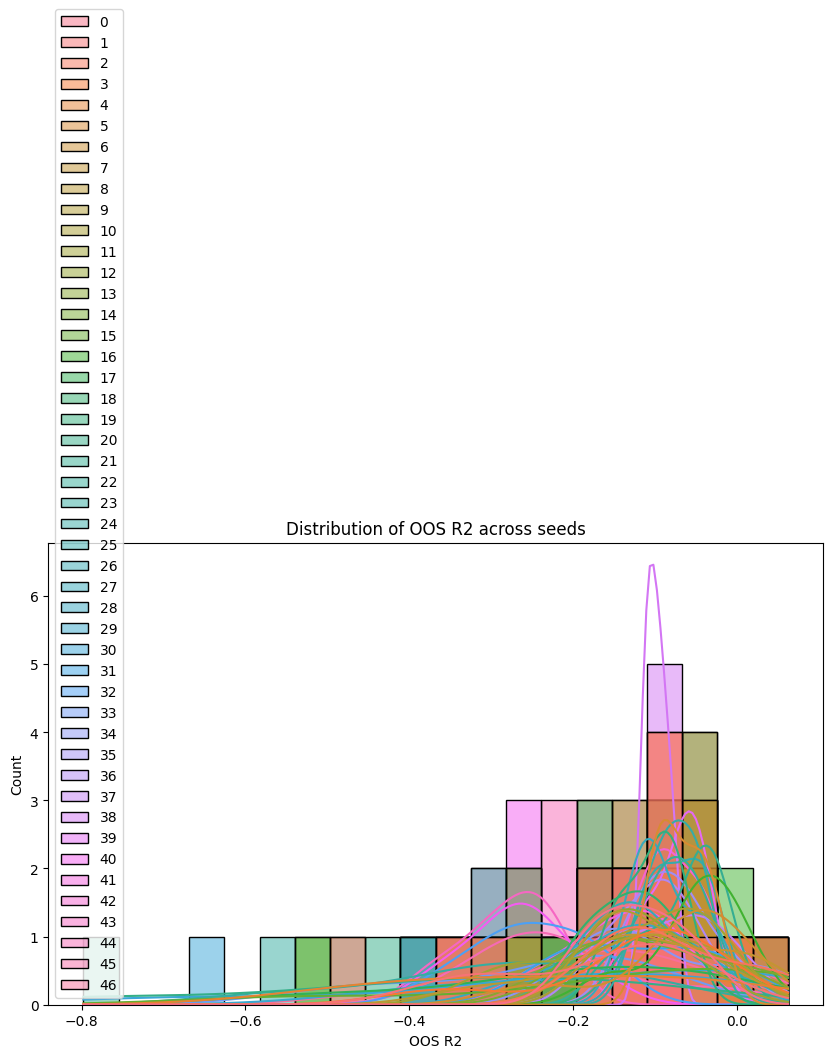

In [20]:
# plot seed_r2s distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.histplot(list(seed_r2s.values()), bins=20, kde=True)
plt.title("Distribution of OOS R2 across seeds")
plt.xlabel("OOS R2")